## **Preamble**

This is the location of the code that will extract radar columns from around the location of the
UND research citation jet during the MC3E field campaign. This code will probably not work many times
and then eventually work when I don't think it will... 

In [30]:
# Libraries
import pyart
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import xarray as xr

In [78]:
# Data read in 
data = pyart.io.read('KTLX20110520_142857_V03.gz')
#dir(data)

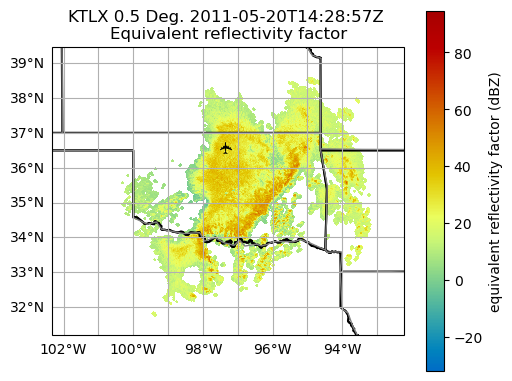

In [125]:
# Reflectivity plotting 
display = pyart.graph.RadarMapDisplay(data)

projection = ccrs.PlateCarree()

center_lon = data.longitude['data'][0]
center_lat = data.latitude['data'][0]

data.latitude['data'][0] = center_lat
data.longitude['data'][0] = center_lon

# Establish min and max latitude and longitude to be plotted:
min_lat = center_lat - 3 #subtracting 1.5 degrees lat
max_lat = center_lat + 3 #adding 1.5 degrees lat
min_lon = center_lon - 3 #subtracting 1.5 degrees lon
max_lon = center_lon + 3 #adding 1.5 degrees lon

fig = plt.figure(figsize = (11,9))

ax = fig.add_axes([0.06, 0.50, 0.40, 0.40], projection = projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')

a = display.plot_ppi_map('reflectivity', ax = ax) #Variable name
'''
                     sweep = 0, #Elevation angle
                     vmin = -20, #Min value
                     vmax = 80, #Max value
                     min_lon = min_lon, #Min longitude of plot
                     max_lon = max_lon, #Max longitude of plot
                     min_lat = min_lat, #Min latitude of plot
                     max_lat = max_lat, #Max latitude of plot
                     resolution = '10m', #Projection resolution
                     projection = projection, #Set projection
                     colorbar_flag = 0, #Turn off colorbar; will add manually
                     title_flag = 0, #Turn off title; will add manually
                     ax = ax,
                     fig = fig, #Where to plot data
                     embellish = False, #Turn off default map outlines
                     lat_0 = center_lat, #Center latitude
                     lon_0 = center_lon, #Center longitude
                     cmap = 'NWSRef' #Color scheme for colorbar
                     )
'''
#cax = fig.add_axes([.445, .50, .02, .40])
#display.plot_colorbar(a, cax = cax, orient='vertical', label='Equiv. Refl. Factor (dBZ)')

#ax.set_title('Reflectivity', fontweight = 'bold')

ax.annotate('\u2708', xy = (-97.5, 36.5), fontsize = 12, rotation = 90)

plt.tight_layout()

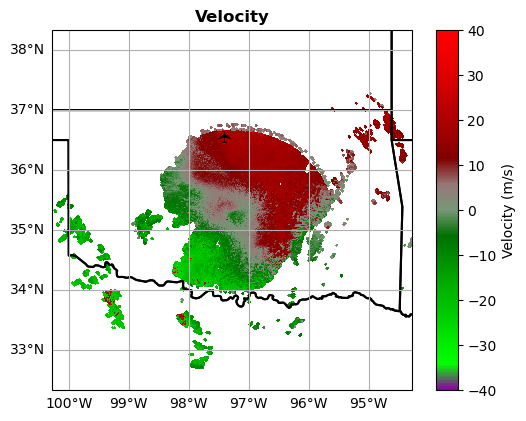

In [113]:
# Velocity plotting 
display = pyart.graph.RadarMapDisplay(data)

projection = ccrs.PlateCarree()

center_lon = data.longitude['data'][0]
center_lat = data.latitude['data'][0]

data.latitude['data'][0] = center_lat
data.longitude['data'][0] = center_lon

# Establish min and max latitude and longitude to be plotted:
min_lat = center_lat - 3 #subtracting 1.5 degrees lat
max_lat = center_lat + 3 #adding 1.5 degrees lat
min_lon = center_lon - 3 #subtracting 1.5 degrees lon
max_lon = center_lon + 3 #adding 1.5 degrees lon

fig = plt.figure(figsize = (11,9))

ax = fig.add_axes([0.06, 0.50, 0.40, 0.40], projection = projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')

a = display.plot_ppi_map('velocity', #Variable name
                     sweep = 1, #Elevation angle
                     vmin = -40, #Min value
                     vmax = 40, #Max value
                     min_lon = min_lon, #Min longitude of plot
                     max_lon = max_lon, #Max longitude of plot
                     min_lat = min_lat, #Min latitude of plot
                     max_lat = max_lat, #Max latitude of plot
                     resolution = '10m', #Projection resolution
                     projection = projection, #Set projection
                     colorbar_flag = 0, #Turn off colorbar; will add manually
                     title_flag = 0, #Turn off title; will add manually
                     ax = ax,
                     fig = fig, #Where to plot data
                     embellish = False, #Turn off default map outlines
                     lat_0 = center_lat, #Center latitude
                     lon_0 = center_lon, #Center longitude
                     cmap = 'NWSVel' #Color scheme for colorbar
                     )

cax = fig.add_axes([.445, .50, .02, .40])
display.plot_colorbar(a, cax = cax, orient='vertical', label='Velocity (m/s)')

ax.set_title('Velocity', fontweight = 'bold')

ax.annotate('\u2708', xy = (-97.5, 36.5), fontsize = 12, rotation = 90)

plt.tight_layout()